Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully

Dataset Loaded Successfully!

First 5 Rows:


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1



EDA Started

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   index                        11055 non-null  int64
 1   having_IPhaving_IP_Address   11055 non-null  int64
 2   URLURL_Length                11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL       

/tmp/ipython-input-832/3327495130.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Result', data=df, palette='viridis')


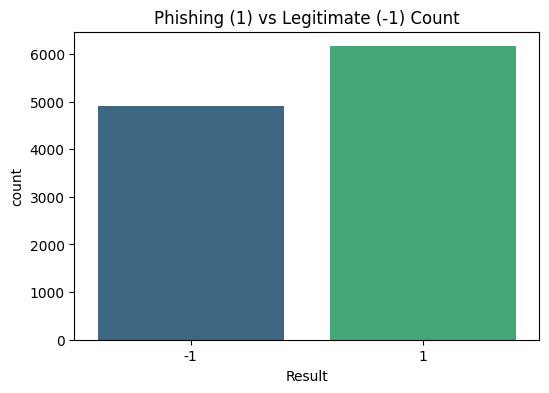


Null Values: 0
Duplicate Rows: 0


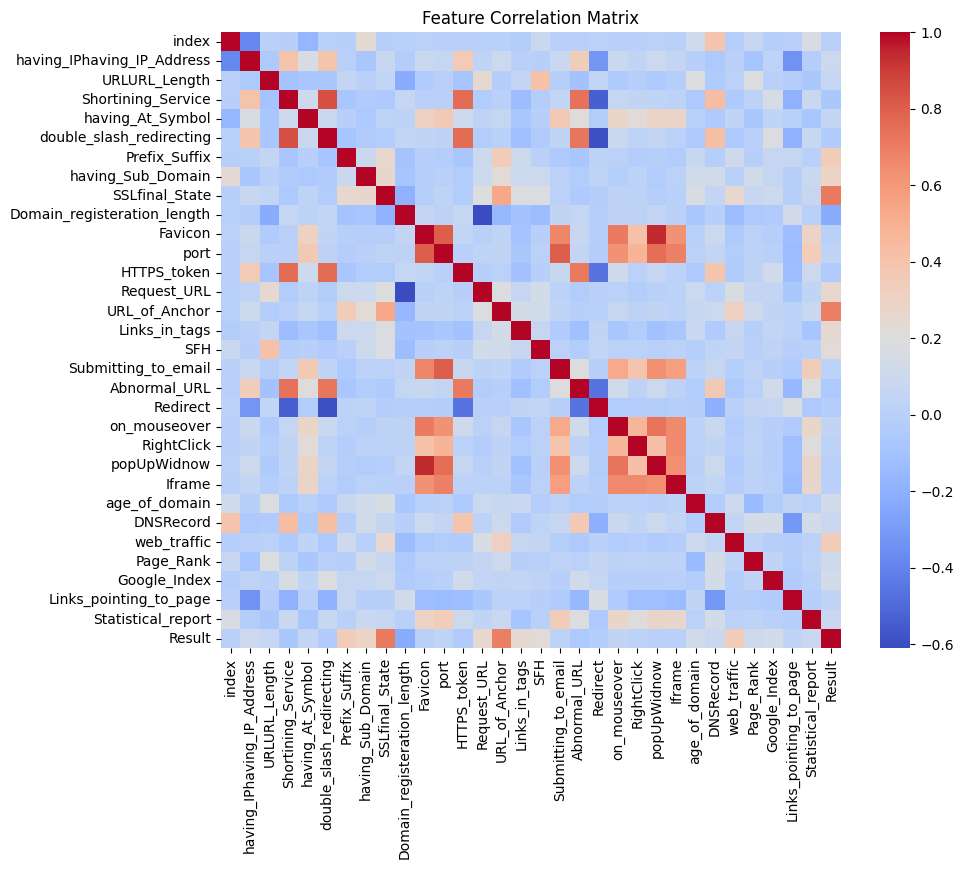


 Preprocessing 

Preprocessing Done!
Training Data Shape: (8844, 31)
Testing Data Shape: (2211, 31)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully")

# STEP 1: LOAD DATASET

filename = '/content/drive/MyDrive/Phishing website detection/dataset.csv'
try:
    df = pd.read_csv(filename)
    print("\nDataset Loaded Successfully!")
except FileNotFoundError:
    print("Dataset Loaded Error")
    df = None

# Check if the data loaded correctly
print("\nFirst 5 Rows:")
if df is not None:
    display(df.head(5))
else:
    print("Dataset could not be loaded. Please check the file path.")


# STEP 2: EDA (Exploratory Data Analysis)

print("\nEDA Started")

# Check if df is loaded before proceeding with EDA
if df is not None:
    # 1. Data information check
    print("\nDataset Info:")
    df.info()

   #2. Target column check

    if 'Result' in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(x='Result', data=df, palette='viridis')
        plt.title("Phishing (1) vs Legitimate (-1) Count")
        plt.show()
    else:

        print("\n'Result' column not found! Check column names:", df.columns)
        print("Assuming the first column as target for demonstration if applicable.")

        if not df.empty:
            target_col = df.columns[0]
            plt.figure(figsize=(6,4))
            sns.countplot(x=target_col, data=df, palette='viridis')
            plt.title(f"Count of {target_col}")
            plt.show()

    # 3. Null value or duplicate check
    print("\nNull Values:", df.isnull().sum().sum())
    print("Duplicate Rows:", df.duplicated().sum())

    # ৪. correlation heatmap

    numeric_df = df.select_dtypes(include=np.number)
    if not numeric_df.empty:
        plt.figure(figsize=(10,8))
        sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False) # annot=False রাখছি যাতে হিজিবিজি না হয়
        plt.title("Feature Correlation Matrix")
        plt.show()
    else:
        print("No numeric columns to plot correlation heatmap.")


    # STEP 3: PREPROCESSING

    print("\n Preprocessing ")

    # 1. If there are any duplicates, delete them (Cleaning)
    if df.duplicated().sum() > 0:
        df = df.drop_duplicates()
        print("Duplicates removed.")

# 2. Remove unnecessary columns (if any) This dataset usually contains 'id' or 'index'. If there are any, we will remove them.

    if 'id' in df.columns:
        df = df.drop('id', axis=1)

    # ৩. Separate Features (X) এবং Target (y)

    if 'Result' in df.columns:
        X = df.drop('Result', axis=1)
        y = df['Result']
    elif not df.empty and len(df.columns) > 1:
        target_column_name = df.columns[0]
        X = df.drop(target_column_name, axis=1)
        y = df[target_column_name]
        print(f"Warning: 'Result' column not found. Using '{target_column_name}' as target for preprocessing.")
    else:
        print("Cannot perform feature/target split: 'Result' column not found and dataset is too small or empty.")
        X, y = None, None # Ensure X and y are not defined for subsequent steps

    # ৪. Train-Test Split
    if X is not None and y is not None:
        from sklearn.model_selection import train_test_split

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        print("\nPreprocessing Done!")
        print(f"Training Data Shape: {X_train.shape}")
        print(f"Testing Data Shape: {X_test.shape}")
    else:
        print("Preprocessing skipped due to missing features or target.")
else:
    print("EDA and Preprocessing skipped because the dataset could not be loaded.")